In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [6]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

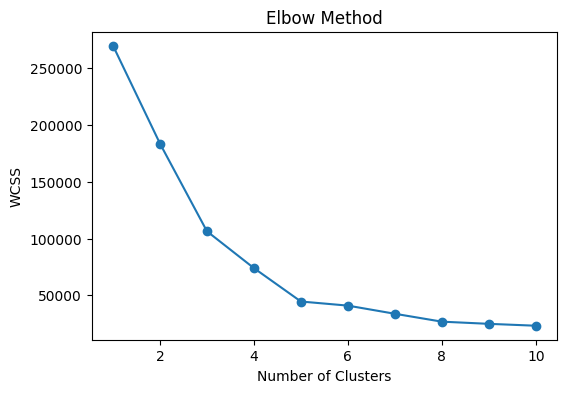

In [7]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

In [9]:
df['Cluster'] = y_kmeans

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


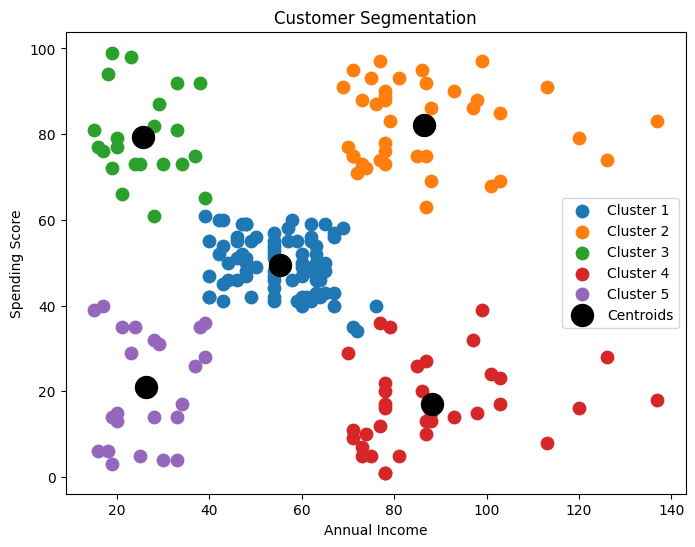

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[y_kmeans==0,0],
    X.iloc[y_kmeans==0,1],
    s=80,
    label='Cluster 1'
)

plt.scatter(
    X.iloc[y_kmeans==1,0],
    X.iloc[y_kmeans==1,1],
    s=80,
    label='Cluster 2'
)

plt.scatter(
    X.iloc[y_kmeans==2,0],
    X.iloc[y_kmeans==2,1],
    s=80,
    label='Cluster 3'
)

plt.scatter(
    X.iloc[y_kmeans==3,0],
    X.iloc[y_kmeans==3,1],
    s=80,
    label='Cluster 4'
)

plt.scatter(
    X.iloc[y_kmeans==4,0],
    X.iloc[y_kmeans==4,1],
    s=80,
    label='Cluster 5'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=250,
    c='black',
    label='Centroids'
)

plt.title('Customer Segmentation')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [11]:
segment_analysis = df.groupby('Cluster').mean(numeric_only=True)

segment_analysis


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


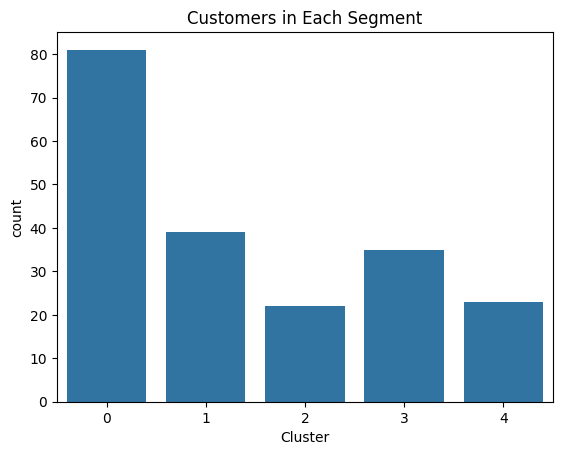

In [12]:
sns.countplot(x='Cluster', data=df)

plt.title('Customers in Each Segment')
plt.show()